<a href="https://colab.research.google.com/github/Kamrul785/Machine-Learning-Engineer-Task/blob/main/Level2_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv("/content/iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
df.nunique()

,0
sepal_length,35
sepal_width,23
petal_length,43
petal_width,22
species,3


In [7]:
df.shape

(150, 5)

## Training Decision Tree

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [9]:
X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
print("Decision Tree Classifier trained Successfully")

Decision Tree Classifier trained Successfully


# visualize the tree structure

In [13]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

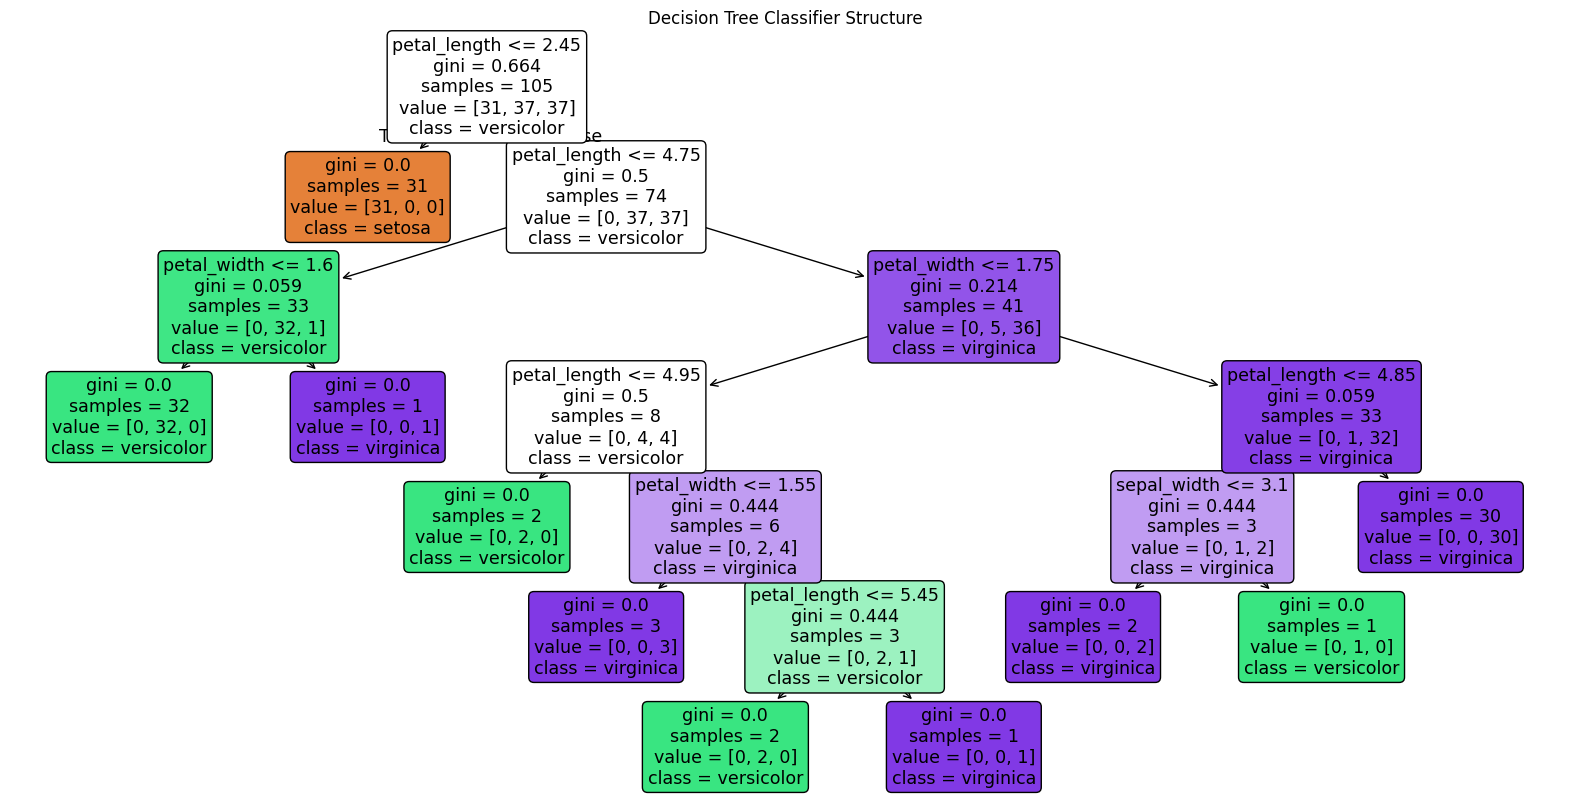

In [15]:
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True, rounded=True)
plt.title("Decision Tree Classifier Structure")
plt.show()

# Prune the tree to prevent overfitting

In [16]:
# To prune the tree, we can limit it's maximum depth or minium samples per leaf.
# Let's try pruning by setting max_depth to a reasonable value , like 3.
pruned_model = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_model.fit(X_train, y_train)
print("Pruned DecisionTree trained")

Pruned DecisionTree trained


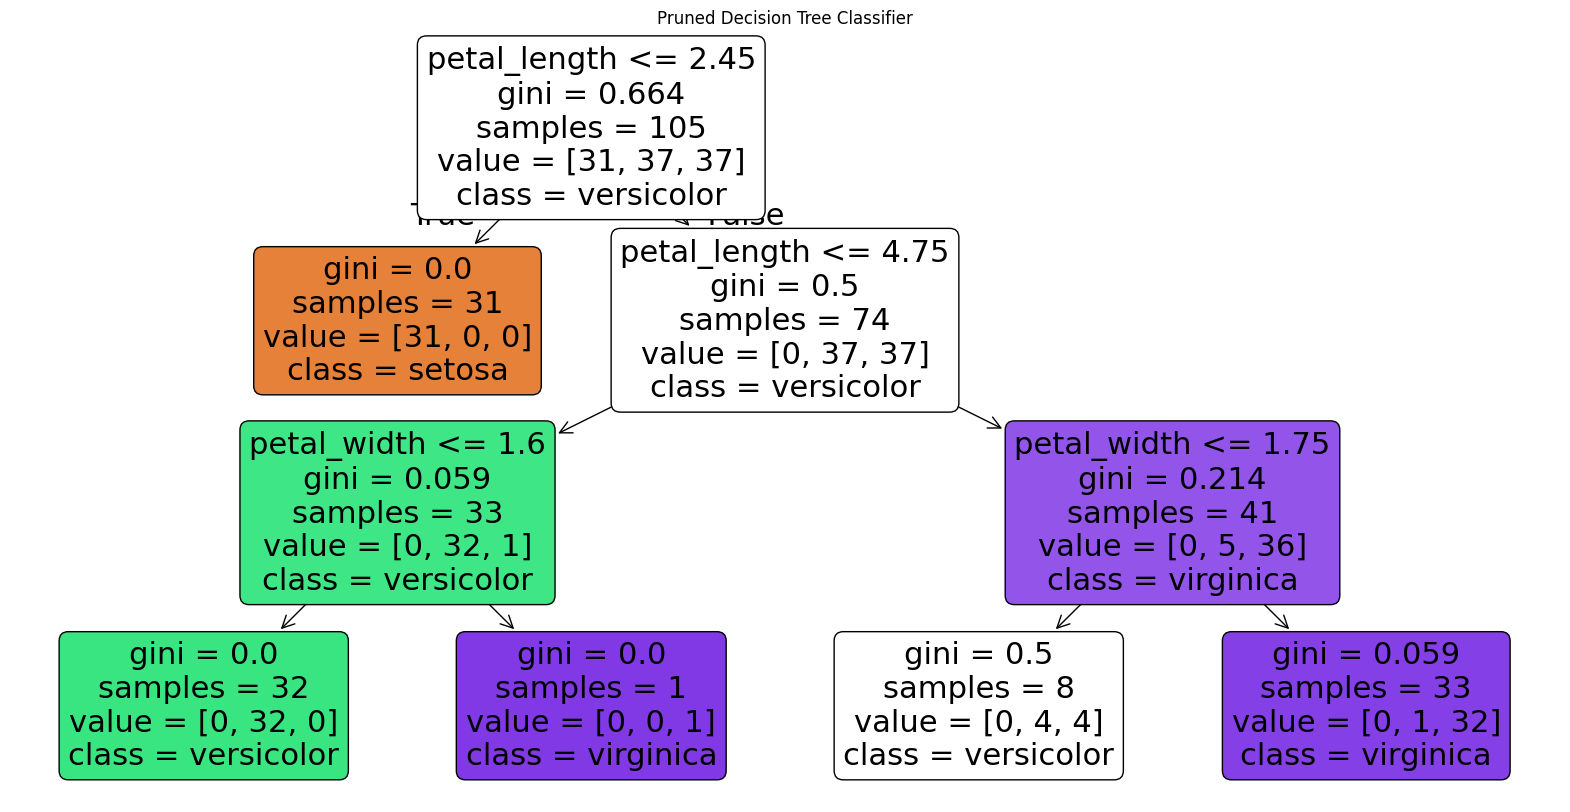

In [17]:
plt.figure(figsize=(20,10))
plot_tree(pruned_model, feature_names=X.columns, class_names=pruned_model.classes_, filled=True, rounded=True)
plt.title("Pruned Decision Tree Classifier")
plt.show()

# Evaluation

In [22]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [25]:
# for original model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}")
print(f"\nClassification Report: \n{report}")

Accuracy : 1.0000

Classification Report: 
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [27]:
# for pruned model
y_pred_pruned = pruned_model.predict(X_test)
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)

print(f"Accuracy: {accuracy_pruned:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_pruned)}")

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

